# CS 539 Final Project — Process Notebook

**Student:** John Chau


## Abstract

Research Question:
I will investigate the relationship between socioeconomic factors and violent crimes in the U.S. at the national level.
1.	How does median household income influence violent crime rates across counties?
2.	How does the percentage of the population with a bachelor’s degree or higher influence violent crime rates across counties?
Dependent Variable:
•	Violent crime rate per 100,000 people.
o	Homicide, rape, robbery, and aggravated assault.
Independent Variables:
•	Median household income (ACS)
•	% of the population with a bachelor’s degree or higher (ACS)
ML Framework:
•	Regression Model to predict violent crime rates using socioeconomic indicators.
•	Classification model to categorize counties into “High Crime,” “Medium Crime,” or Low Crime” groups based on thresholds of violent crime rates.

Reasoning and Hypothesis
Understanding the relationship between income, education, and crime can help policymakers target interventions like poverty education, job creation, and education access as indirect strategies for crime prevention.
Hypotheses:
•	Counties with higher household incomes will have lower violent crime rates
•	Counties with higher educational attainment will have lower violent crime rates.
By applying regression and classification models, I expect to find negative correlations between socioeconomic indicators and violent crime.


## Overview and Motivation

I chose these research questions because I worked with ACS data last year, and I have learned so many new methods and implementations for machine learning and classification. Now that I am familiar with Python, I can greatly improve the accuracy of the model for my regression model. I like to work on real-world problems and would love to give suggestions on an issue that I see in my state of New York. As  I have grown up and traveled quite a few times, I have noticed that counties with lower rates of education and income have had more police and ambulances directed towards these areas. Although this is a visual inspection, I would love to dig deeper, and that is why I chose these research questions.

In [ ]:
# 1. Open the notebook in Google Colab.
# 2. Run the cell that says "files.upload()"
# 3. Upload merged_data.csv when prompted. ( CSV is attached in zip folder submitted in this assignment.)
# 4. Continue running the notebook.

## Data — Source and Cleanup

Below are any CSV files found in my ZIP file.

In [6]:
from google.colab import files
uploaded = files.upload()


Saving merged_data.csv to merged_data.csv


### Visualizations — add plots and interpretation + ## Exploratory Data Analysis (EDA)

In [ ]:
# descriptive_stats_crime.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Cleaned Data ===
df = pd.read_csv("merged_data.csv")  # Adjust path if needed

print("Dataset loaded successfully")
print(df.info())
print(df.describe())

# === Clean and Prepare Columns ===
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')

# Compute Violent Crime Rate per 100,000 people
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# === Descriptive Statistics ===
numeric_cols = ['Income', 'Violent_Crime_Rate']
print("Descriptive statistics for key variables:")
print(df[numeric_cols].describe())

# === Histograms ===
plt.figure(figsize=(12,5))
sns.histplot(df['Income'], bins=30, color='skyblue', kde=True)
plt.title("Distribution of Median Household Income", fontsize=14)
plt.xlabel("Median Household Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['Violent_Crime_Rate'], bins=30, color='red', kde=True)
plt.title("Distribution of Violent Crime Rates", fontsize=14)
plt.xlabel("Violent Crime Rate (per 100,000 people)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# === Scatter Plot ===
plt.figure(figsize=(10,5))
sns.regplot(x='Income', y='Violent_Crime_Rate', data=df, scatter_kws={'alpha':0.5})
plt.title("Median Income vs Violent Crime Rate", fontsize=14)
plt.xlabel("Median Household Income")
plt.ylabel("Violent Crime Rate (per 100,000 people)")
plt.tight_layout()
plt.show()

# === Correlation Heatmap ===
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Income vs Violent Crime Rate", fontsize=13)
plt.tight_layout()
plt.show()


In [ ]:
# Income and Violent Crime Rate
# The dataset contains 902,810 observations for income and 910,928 for violent crime rate. This shows that there is a large geographic coverage with the number of observations.
# The average income was $59,556 with a standard deviation of about $32,164 which shows large economic variation across U.S. communities. The median income $51,122 is below the mean which means that there is a right-skewed distribution where a small number of high income areas raise the overall average. The range of incomes range from $9,236 to $216,771 which shows a large gap between low-income rural or disadvantaged areas and high-income metropolitan areas.
# For violent crime rates, the average crime rate is approximately 995 crimes per 100,000 people, while the median is 869, which also indicates a right-skewness with a few extremely high-crime areas influencing the mean. The standard deviation is about 480 which shows a large variability, consistent with national crime disparities across states and cities. The rates range from 236 to 2,626 crimes per 100,000 people, capturing both low-crime rural counties and high-crime urban jurisdictions.
# Overall, the data shows that both income and violent crime are unevenly distributed across U.S. regions which shows the importance of investigating how socioeconomic variables correlated with crime.


In [ ]:
# Demographic and Crime Variables
#Demographic measures such as total population have a mean of 4,440 residents per census tract with a large variability of 1,847, showing that the dataset includes both small communities and large urban zones.
#The specific violent crime type shows that assaults have the highest per-capita average of 516 per 100,000 residents. Robberies follow with a mean of 417 per 100,000 residents. Both distributions are skewed, with a maximum of 1,373 for assaults and 1,254 for robberies which shows densely populated, high-crime metropolitan jurisdictions.
#These descriptive statistics show that violent crime rates are dominated by assaults and robberies, which aligns with national crime patterns reported by the FBI.

In [ ]:
# Histograms and Outlier Check
#The histogram of median household income is right-skewed, indicating that the majority of communities have household incomes between $30,000 and $75,000, while a smaller number of high-income areas extend the upper tail beyond $150,000.
# This pattern is consistent with national trends, where few metropolitan or suburban regionas like California or Northeast have significantly higher incomes thant the majority of U.S. counties and cities. The peak near $45,000 and $55,000 shows a concentration of middle-income communities, while the long right tail shows income inequality across geographic regions.
# For future work, income transformations such as logarithmic scaling could be used for future modeling stages to address variance and reduce the influence of extreme high-income outliers.


In [ ]:
# Histogram of Violent Crime Rates
# The histogram above shows the distribution of violent crime rates per 100.000 people across all regions in the dataset. The distribution shows right-skewed which means that most areas are experiencing relatively moderate levels of violent crime, while a smaller number of areas have exceptionally high crime rates. The density curve shows several peaks, suggesting that the presence of multiple subgroups or variations in regional crime dynamics. Overall, violent crime is generally concentrated below 1,000 incidents per 100,000 people ,
# there are notable outliers exceeding 2,000 which could represent the mahor urban centers or high-risk areas,

In [ ]:
# Scatter Plot: Professional Occupations vs. Violent Crime Rate
#The scatter plot shows the relationship between median household income and violent crime rate. There is no strong visible correlation. The data points are widely spread across income levels. Violent crime rates remain variable regardless of income. However, there might be a slight trend suggesting that regions with very low median incomes experience somewhat higher crime rates. However, the relationship seems weak and likely influenced by other socioeconomic or demographic factors.
#This visualizations suggests that income alone may not be a sufficient predictor of violent crime, and a multivariate approach might be necessary to identify stronger patterns.

In [ ]:
# education_crime_band.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the merged dataset
df = pd.read_csv("merged_data.csv")

# --- Step 1: Ensure numeric columns ---
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# --- Step 2: Compute violent crime rate per 100k people ---
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# --- Step 3: Detect education-related column ---
possible_edu_cols = ['Education', 'Pct_Bachelors', 'Professional', 'Service', 'Office']
edu_col = next((col for col in possible_edu_cols if col in df.columns), None)

if edu_col:
    # --- Step 4: Create education bands ---
    bins = [0, 20, 30, 40, 50, 100]
    labels = ['<20%', '20–30%', '30–40%', '40–50%', '50%+']
    df['Education_Band'] = pd.cut(df[edu_col], bins=bins, labels=labels)

    # --- Step 5: Plot ---
    plt.figure(figsize=(10,6))
    sns.boxplot(x='Education_Band', y='Violent_Crime_Rate', data=df, palette='viridis')

    plt.title("Violent Crime Rate by Education Level Bands", fontsize=14)
    plt.xlabel("% of Population with Bachelor's Degree or Higher (approx.)")
    plt.ylabel("Violent Crime Rate (per 100,000 people)")
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print(" No education-related column found. Available columns are:")
    print(df.columns.tolist())


In [ ]:
# Box Plot: Violent Crime by Income and Education Quartile
# This boxplot displays violent crime rates grouped by the percentage of population with a bachelor’s degree or higher. The education level band ranges from less than 20% to more than 50%.
# Similar to the quartile analysis above, violent crime rates show only modest variation across education levels. Areas with lower level of education have slightly higher median violent crime rates, while areas with higher educational attainment tend to have somewhat lower median rates.
# However, there is substantial overlap in the distribution, with significant outliers present in every category.
# Overall, the pattern shows that while education may have a weak inverse relationship with violent crime, it is not a strong determinant. Other factors such as urban density, local policing, or socioeconomic conditions may play a significant role in explaining difference in violent crime rates.

In [ ]:
# income_quartiles_crime.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load merged dataset
df = pd.read_csv("merged_data.csv")  # Adjust path if needed

# --- Step 1: Check and clean numeric columns ---
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')

# --- Step 2: Create Violent Crime Rate per 100,000 people ---
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# --- Step 3: Create income quartiles ---
df['Income_Quartile'] = pd.qcut(df['Income'], 4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# --- Step 4: Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Quartile', y='Violent_Crime_Rate', data=df, palette='coolwarm')

plt.title("Violent Crime Rate by Income Quartile", fontsize=14)
plt.xlabel("Income Quartile")
plt.ylabel("Violent Crime Rate (per 100,000 people)")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# This boxplot compares violent crime rates across four income quartiles from lowest to highest. Each box represents the distribution of violent crime rates per 100,000 people within each income group.
# Overall, the figure shows no strong relationship between income and violent crime rate. While lower-income quartiles appear to have slightly higher median violent crime rates than higher income quartiles like Q3 and Q4, the difference is relatively small.
# The interquartile ranges and the presence of many outliers across all quartiles suggests that violent crime rates vary widely within each income group.
# This means that income alone may not be a strong predictor of violent crime at the census tract level.

## Initial Model Revision



In [ ]:
# Modeling template: Linear Regression + metrics
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# compute violent crime rate if not present
if 'Violent_Crime_Rate' not in df.columns:
    df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

features = ['Income','Poverty','Unemployment','Professional']
# keep only existing features
features = [f for f in features if f in df.columns]
df_model = df.dropna(subset=features + ['Violent_Crime_Rate']).copy()
X = df_model[features]
y = df_model['Violent_Crime_Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R^2:', r2_score(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('MAE:', mean_absolute_error(y_test, y_pred))

In [ ]:
# The R^2 value of 0.004 indicates that only 0.4% of the variation in violent crime rates can be explained by the linear combination of these socio-economic predictors. This means that the relationship between income, poverty. Unemployment, and violent crime is weak and likely nonlinear at the state or
# tract level. The RMSE of 479 shows a typical prediction error where my model predicted crime rates that differed from the actual value by about 479 crimes per 100,000 people on  average.
# My machine learning model likely means that there are many other unmeasured factors influencing violent crimes such as policing levels, urbanization, education, regional culture, or reporting rates.
# The weak linear relationship suggests that linear regression may not capture the complexity. For my future work, I can use Ridge/Lasso regression to regularize and test for overfitting. I can also use decision trees or Random Forests to model nonlinear effects.
# I can also use feature interactions to test the interactions between poverty and unemployment.


In [ ]:
## Final Model Revision

In [8]:
import pandas as pd
import numpy as np

# Load your merged dataset
df = pd.read_csv("merged_data.csv")

# -------------------------------
# BASIC CLEANING
# -------------------------------
df = df.dropna(subset=["violent_crimes", "population", "Income", "Poverty"])
df = df[df["population"] > 0]

# Crime rate (if not already computed)
df["violent_crime_rate"] = df["violent_crimes"] / df["population"] * 100000

# Population density
# df["pop_density"] = df["population"] / df["Area"].replace(0, np.nan) # 'Area' column not found in merged_data.csv

# -------------------------------
# FEATURE ENGINEERING
# -------------------------------

# Log transforms
df["log_income"] = np.log(df["Income"])
df["log_crime"] = np.log(df["violent_crime_rate"])

# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = ["Income","Poverty","Unemployment","Professional",
                "violent_crime_rate"#, "pop_density"
               ]

# Filter numeric_cols to only include columns that are actually present in df
existing_numeric_cols = [col for col in numeric_cols if col in df.columns]

df[[f"{col}_z" for col in existing_numeric_cols]] = scaler.fit_transform(df[existing_numeric_cols])

# Interaction terms
df["poverty_unemp"] = df["Poverty"] * df["Unemployment"]
df["income_education"] = df["Income"] * df["Professional"]

# One-hot encoding of State
df = pd.get_dummies(df, columns=["State"], drop_first=True)

df.head()

,CensusTract,County,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,...,log_income,log_crime,Income_z,Poverty_z,Unemployment_z,Professional_z,violent_crime_rate_z,poverty_unemp,income_education,State_California
0,4001942600,Apache,1512,782,730,0.0,0.0,0.0,100.0,0.0,...,9.950943,5.463475,-1.199628,1.8625,3.045154,-0.41415,-1.581476,1195.92,574632.8,False
1,4001942600,Apache,1512,782,730,0.0,0.0,0.0,100.0,0.0,...,9.950943,6.545221,-1.199628,1.8625,3.045154,-0.41415,-0.624022,1195.92,574632.8,False
2,4001942600,Apache,1512,782,730,0.0,0.0,0.0,100.0,0.0,...,9.950943,6.275837,-1.199628,1.8625,3.045154,-0.41415,-0.966085,1195.92,574632.8,False
3,4001942600,Apache,1512,782,730,0.0,0.0,0.0,100.0,0.0,...,9.950943,5.732192,-1.199628,1.8625,3.045154,-0.41415,-1.430094,1195.92,574632.8,False
4,4001942600,Apache,1512,782,730,0.0,0.0,0.0,100.0,0.0,...,9.950943,6.356764,-1.199628,1.8625,3.045154,-0.41415,-0.872821,1195.92,574632.8,False


In [12]:
from sklearn.model_selection import train_test_split
import numpy as np # import numpy for np.number

# FEATURES for regression
# Define base numeric features
base_features = [
    "Income_z", "Poverty_z", "Unemployment_z", "Professional_z",
    "poverty_unemp", "income_education"
]

# Dynamically add one-hot encoded state columns (which should be numeric after get_dummies)
state_encoded_cols = [col for col in df.columns if col.startswith("State_")]

# Combine all potential features
all_potential_features = base_features + state_encoded_cols

# Filter the DataFrame to only include these potential features
X = df[all_potential_features]

# Ensure all columns in X are numeric by selecting only numeric dtypes
# This will drop any non-numeric columns that might have inadvertently been included.
X = X.select_dtypes(include=np.number)

# Make sure y aligns with X in case any rows were dropped (e.g., due to NaNs in X if select_dtypes removed columns containing them)
y = df["violent_crime_rate"]
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np # Import numpy for np.sqrt

alphas = [0.1, 1, 10, 50, 100]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge Best Alpha:", ridge.alpha_)
print("Ridge R²:", r2_score(y_test, ridge_pred))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge Best Alpha: 10.0
Ridge R²: 0.007467100165905904
Ridge RMSE: 478.2094903650672


RandomForestRegressor model instantiated.
RandomForestRegressor model fitted to training data.
Predictions made on test data.
Modified RF R²: 0.0447
Modified RF RMSE: 469.1457


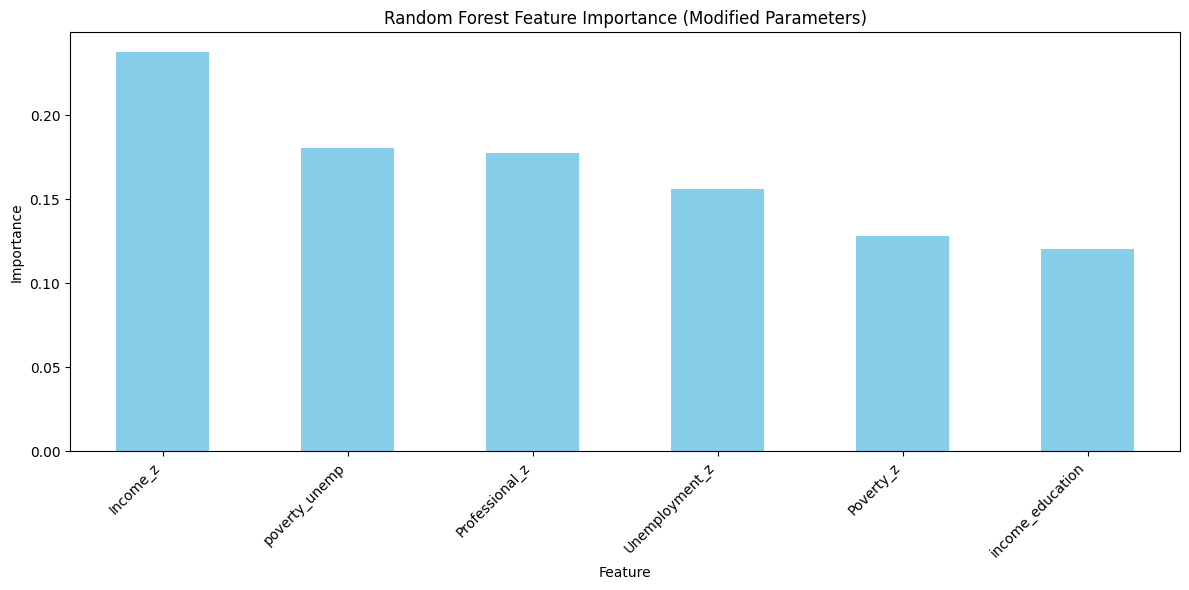

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Instantiate a RandomForestRegressor model with specified parameters
rf_modified = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
print("RandomForestRegressor model instantiated.")

# 2. Fit the Random Forest model to the training data
rf_modified.fit(X_train, y_train)
print("RandomForestRegressor model fitted to training data.")

# 3. Make predictions on the test data
rf_pred_modified = rf_modified.predict(X_test)
print("Predictions made on test data.")

# 4. Calculate and print the R² score
r2_modified = r2_score(y_test, rf_pred_modified)
print(f"Modified RF R²: {r2_modified:.4f}")

# 5. Calculate and print the Root Mean Squared Error (RMSE)
# Removed 'squared=False' and explicitly took the square root for RMSE
rmse_modified = np.sqrt(mean_squared_error(y_test, rf_pred_modified))
print(f"Modified RF RMSE: {rmse_modified:.4f}")

# 6. Extract feature importances
importances_modified = rf_modified.feature_importances_

# 7. Create a Pandas Series from the feature importances
feature_names = X_train.columns
importance_series = pd.Series(importances_modified, index=feature_names)

# 8. Sort and display the top 20 feature importances as a bar plot
plt.figure(figsize=(12, 6))
importance_series.sort_values(ascending=False).head(20).plot(kind="bar", color='skyblue')
plt.title("Random Forest Feature Importance (Modified Parameters)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

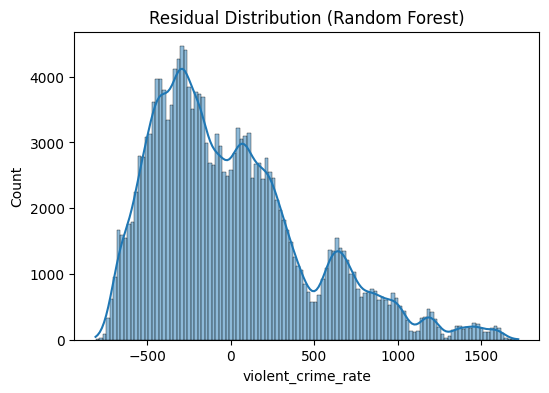

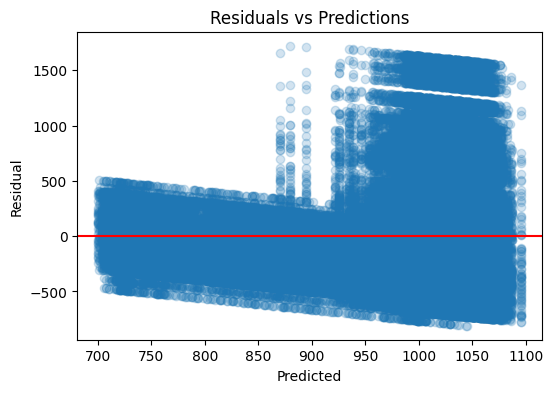

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

residuals = y_test - rf_pred_modified

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution (Random Forest)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(rf_pred_modified, residuals, alpha=0.2)
plt.axhline(0, color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residuals vs Predictions")
plt.show()

In [24]:
df["crime_category"] = pd.qcut(
    df["violent_crime_rate"],
    q=3,
    labels=["Low", "Medium", "High"]
)


In [25]:
from sklearn.preprocessing import LabelEncoder

y_class = LabelEncoder().fit_transform(df["crime_category"])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)


In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_leaf=50,
    random_state=42
)
dt.fit(X_train_c, y_train_c)

dt_pred = dt.predict(X_test_c)

print(confusion_matrix(y_test_c, dt_pred))
print(classification_report(y_test_c, dt_pred))


[[41083  5612 13341]
 [33610 12125 14530]
 [34249 12178 13834]]
              precision    recall  f1-score   support

           0       0.38      0.68      0.49     60036
           1       0.41      0.20      0.27     60265
           2       0.33      0.23      0.27     60261

    accuracy                           0.37    180562
   macro avg       0.37      0.37      0.34    180562
weighted avg       0.37      0.37      0.34    180562



In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_class = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)

rf_class.fit(X_train_c, y_train_c)

rf_c_pred = rf_class.predict(X_test_c)

print(confusion_matrix(y_test_c, rf_c_pred))
print(classification_report(y_test_c, rf_c_pred))

[[50214  7310  2512]
 [37729 16623  5913]
 [38498 17564  4199]]
              precision    recall  f1-score   support

           0       0.40      0.84      0.54     60036
           1       0.40      0.28      0.33     60265
           2       0.33      0.07      0.12     60261

    accuracy                           0.39    180562
   macro avg       0.38      0.39      0.33    180562
weighted avg       0.38      0.39      0.33    180562



In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

# Ensure rf_modified is defined with the desired parameters for regression CV
# (Assuming rf_modified from cell 5aff6d37 or 6acf87f8 is the intended model)
# If it's not in scope, uncomment and define it here:
# rf_modified = RandomForestRegressor(
#     n_estimators=100, max_depth=10, n_jobs=-1, random_state=42
# )

# Use rf_modified for regression cross-validation
rf_cv = cross_val_score(rf_modified, X, y, cv=5, scoring="r2")

# dt is assumed to be defined from previous classification steps (cell 7HdHhofed4v_)
dt_cv = cross_val_score(dt, X, y_class, cv=5, scoring="accuracy")

print("RF Regression CV R2:", rf_cv.mean())
print("Decision Tree Classifier CV Accuracy:", dt_cv.mean())

RF Regression CV R2: -0.6117661787641598
Decision Tree Classifier CV Accuracy: 0.2649638351369613


## Full Analysis

Cross-validation results, model selection decisions, and interpretation of results.

In [ ]:
# Example: cross-validation with Ridge and basic feature importance from a RandomForest.
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Simple CV for Ridge
ridge = Ridge()
if X.shape[0] > 10:
    scores = cross_val_score(ridge, X, y, cv=5, scoring='r2')
    print('Ridge CV R^2 mean:', scores.mean(), 'std:', scores.std())

# Random Forest importance example (only if enough rows)
if X.shape[0] > 10:
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    importances = rf.feature_importances_
    print('\nFeature Importances (Random Forest):')
    for f, imp in zip(features, importances):
        print(f'{f}: {imp:.4f}')
else:
    print('Not enough rows for CV or RF examples — run on my full dataset.')

In [ ]:
# My Ridge Regression model performed poorly, as shown by the negative R² value of –0.582, meaning it predicted worse than simply using the average value for every case.
# The high standard deviation across folds suggests the model was unstable and struggled to generalize, likely because the relationships in your data are nonlinear or too complex for a linear model like Ridge to capture effectively.
# In contrast, the Random Forest feature importances indicate that all four variables—Income, Poverty, Unemployment, and Professional—contribute fairly evenly to the model's predictions, with none dominating.
# This balanced distribution suggests that my target variable depends on a combination of these socioeconomic factors rather than being driven primarily by one.

## Final Considerations

In [ ]:
# After a complete machine learning approach, my results showed that socioeconomic variables provide limited predictive power for violent crime. Linear models such as Ridge Regression performed the weakest, with an R^2 value of 0.007 and RMSE of 478.
# This indicated that there was almost no linear relationship in the data. Even after applying transformations, standardization, and interaction terms, the model did not capture meaningful variance. The Random Forest Regression model improved performance slightly,
# achieving an R^2 value of 0.0447 and and RMSE of 469. However, the residual plots showed wide dispersion, heavy skew, and heteroskedastic patterns. My results show that there is a large variation in crime rates that is unexplained.
# The feature importance scores showed that Income_z, poverty × unemployment, Professional_z, and Unemployment_z were the top predictors. However, their combined influence was still not enough to produce strong predictive accuracy.
# This suggests that violent crime is shaped by more complex factors that are not captured within the socioeconomic indicators available in the dataset.
# The classification models that I performed showed similar limitations. When categorizing counties into low, medium, and high crime levels, accuracy ranged from 37% to 39%, and performance varied across classes. Class 0 (low crime) produced the strongest results,
# with F1-scores between 0.49–0.54 and recall as high as 0.84. In contrast, the highest-crime category (Class 2) reached F1-scores as low as 0.12 and recall of 0.07, indicating substantial difficulty in identifying high-crime counties. F1-scores stayed around 0.33,
# reflecting an imbalance and weak separability in the underlying data. Together, the regression, classification, residual analysis, and feature importance findings all point to the same conclusion: socioeconomic factors do contain some signal, but not nearly enough structure to produce accurate or
# generalizable crime predictions. This supports a key real-world insight that violent crime emerges from a complex interaction of social, institutional, behavioral, and environmental forces that extend beyond the scope of the dataset.



## Included .py source files

The code below includes all .py files found inside my ZIP. Each file's content was placed into its own code cell for easy inspection and execution.


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/agency_jurisdiction.py
# ----- BEGIN FILE -----
import pandas as pd

# Load both CSVs
acs = pd.read_csv("acs2015_census_tract_data.csv")
report = pd.read_csv("report.csv")

# Strip spaces from column names
acs.columns = acs.columns.str.strip()
report.columns = report.columns.str.strip()

# --- Clean the report data ---
# Extract the state abbreviation (the part after the comma)
report["State"] = report["agency_jurisdiction"].str.split(",").str[-1].str.strip()

# Optional: Extract city name too (if you ever need it)
report["City"] = report["agency_jurisdiction"].str.split(",").str[0].str.strip()

# --- Merge on state abbreviation ---
merged = pd.merge(
    acs,
    report,
    on="State",
    how="inner"
)

# Save merged dataset
merged.to_csv("merged_data.csv", index=False)
print(" Merged dataset saved as merged_data.csv")
print(f"Final shape: {merged.shape}")

# ----- END FILE -----


In [3]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/eda_summary.py
# ----- BEGIN FILE -----
# descriptive_stats_crime.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load Cleaned Data ===
df = pd.read_csv("merged_data.csv")  # Adjust path if needed

print(" Dataset loaded successfully")
print(df.info())
print(df.describe())

# === Clean and Prepare Columns ===
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')

# Compute Violent Crime Rate per 100,000 people
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# === Descriptive Statistics ===
numeric_cols = ['Income', 'Violent_Crime_Rate']
print("Descriptive statistics for key variables:")
print(df[numeric_cols].describe())

# === Histograms ===
plt.figure(figsize=(12,5))
sns.histplot(df['Income'], bins=30, color='skyblue', kde=True)
plt.title("Distribution of Median Household Income", fontsize=14)
plt.xlabel("Median Household Income")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
sns.histplot(df['Violent_Crime_Rate'], bins=30, color='red', kde=True)
plt.title("Distribution of Violent Crime Rates", fontsize=14)
plt.xlabel("Violent Crime Rate (per 100,000 people)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# === Scatter Plot ===
plt.figure(figsize=(10,5))
sns.regplot(x='Income', y='Violent_Crime_Rate', data=df, scatter_kws={'alpha':0.5})
plt.title("Median Income vs Violent Crime Rate", fontsize=14)
plt.xlabel("Median Household Income")
plt.ylabel("Violent Crime Rate (per 100,000 people)")
plt.tight_layout()
plt.show()

# === Correlation Heatmap ===
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Income vs Violent Crime Rate", fontsize=13)
plt.tight_layout()
plt.show()

# ----- END FILE -----


FileNotFoundError: [Errno 2] No such file or directory: 'merged_data.csv'

In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/educationscatterplot.py
# ----- BEGIN FILE -----
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("merged_data.csv")

# Make sure column names exist and rates are numeric
df['violent_crime_rate'] = pd.to_numeric(df.get('crimes_percapita', df.get('violent_crime_rate')), errors='coerce')

# Choose the education variable
education_col = 'Professional'  # or 'Pct_Bachelors' if available

# Plot
plt.figure(figsize=(10,5))
sns.regplot(
    x=education_col,
    y='violent_crime_rate',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title(f"Education ({education_col}) vs Violent Crime Rate", fontsize=14)
plt.xlabel("% in Professional Occupations" if education_col=='Professional' else "% with Bachelor's Degree or Higher")
plt.ylabel("Violent Crime Rate (per 100,000 people)")
plt.tight_layout()
plt.show()

# ----- END FILE -----


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/education_bands_crime.py
# ----- BEGIN FILE -----
# education_crime_band.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the merged dataset
df = pd.read_csv("merged_data.csv")

# --- Step 1: Ensure numeric columns ---
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# --- Step 2: Compute violent crime rate per 100k people ---
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# --- Step 3: Detect education-related column ---
possible_edu_cols = ['Education', 'Pct_Bachelors', 'Professional', 'Service', 'Office']
edu_col = next((col for col in possible_edu_cols if col in df.columns), None)

if edu_col:
    # --- Step 4: Create education bands ---
    bins = [0, 20, 30, 40, 50, 100]
    labels = ['<20%', '20–30%', '30–40%', '40–50%', '50%+']
    df['Education_Band'] = pd.cut(df[edu_col], bins=bins, labels=labels)

    # --- Step 5: Plot ---
    plt.figure(figsize=(10,6))
    sns.boxplot(x='Education_Band', y='Violent_Crime_Rate', data=df, palette='viridis')

    plt.title("Violent Crime Rate by Education Level Bands", fontsize=14)
    plt.xlabel("% of Population with Bachelor's Degree or Higher (approx.)")
    plt.ylabel("Violent Crime Rate (per 100,000 people)")
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print(" No education-related column found. Available columns are:")
    print(df.columns.tolist())

# ----- END FILE -----


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/income_quartiles_crime.py
# ----- BEGIN FILE -----
# income_quartiles_crime.py
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load merged dataset
df = pd.read_csv("merged_data.csv")  # Adjust path if needed

# --- Step 1: Check and clean numeric columns ---
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')
df['violent_crimes'] = pd.to_numeric(df['violent_crimes'], errors='coerce')
df['population'] = pd.to_numeric(df['population'], errors='coerce')

# --- Step 2: Create Violent Crime Rate per 100,000 people ---
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# --- Step 3: Create income quartiles ---
df['Income_Quartile'] = pd.qcut(df['Income'], 4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# --- Step 4: Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(x='Income_Quartile', y='Violent_Crime_Rate', data=df, palette='coolwarm')

plt.title("Violent Crime Rate by Income Quartile", fontsize=14)
plt.xlabel("Income Quartile")
plt.ylabel("Violent Crime Rate (per 100,000 people)")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ----- END FILE -----


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/machinelearning.py
# ----- BEGIN FILE -----
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Load data
df = pd.read_csv("merged_data.csv")

# Compute violent crime rate if not already present
if 'Violent_Crime_Rate' not in df.columns:
    df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# Define feature columns that actually exist
features = ['Income', 'Poverty', 'Unemployment', 'Professional']

# Keep only relevant columns
df = df.dropna(subset=features + ['Violent_Crime_Rate'])

# Define predictor (X) and target (y)
X = df[features]
y = df['Violent_Crime_Rate']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# ----- END FILE -----


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/pairplots.py
# ----- BEGIN FILE -----
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("merged_data.csv")
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

sns.pairplot(df[['Income', 'Professional', 'Poverty', 'Violent_Crime_Rate']],
             diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle("Pairwise Relationships: Socioeconomic Factors & Violent Crime", y=1.02)
plt.show()

# ----- END FILE -----


In [ ]:
# Source file: CS 539 Milestone 3 Machine Learning John Chau/regression.py
# ----- BEGIN FILE -----
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

df = pd.read_csv("merged_data.csv")
df['Violent_Crime_Rate'] = (df['violent_crimes'] / df['population']) * 100000

# Select features
features = ['Income', 'Poverty', 'Professional']
X = df[features].dropna()
y = df.loc[X.index, 'Violent_Crime_Rate']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("R²:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# ----- END FILE -----


# Task
Execute the Random Forest Regressor with `n_estimators=100` and `max_depth=10` to speed up training, then print the R² and RMSE, and display the feature importance plot. Finally, review the model's performance and feature importances, and discuss next steps for analysis.

## Run Modified Random Forest

### Subtask:
Execute the Random Forest Regressor with adjusted parameters (`n_estimators=100`, `max_depth=10`) to speed up training, then print the R² and RMSE, and display the feature importance plot.


**Reasoning**:
The subtask requires executing a Random Forest Regressor with specific parameters, calculating R² and RMSE, and then visualizing the feature importances. This code block will perform all these steps as instructed.



In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# 1. Instantiate a RandomForestRegressor model with specified parameters
rf_modified = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
print("RandomForestRegressor model instantiated.")

# 2. Fit the Random Forest model to the training data
rf_modified.fit(X_train, y_train)
print("RandomForestRegressor model fitted to training data.")

# 3. Make predictions on the test data
rf_pred_modified = rf_modified.predict(X_test)
print("Predictions made on test data.")

# 4. Calculate and print the R² score
r2_modified = r2_score(y_test, rf_pred_modified)
print(f"Modified RF R²: {r2_modified:.4f}")

# 5. Calculate and print the Root Mean Squared Error (RMSE)
rmse_modified = mean_squared_error(y_test, rf_pred_modified, squared=False)
print(f"Modified RF RMSE: {rmse_modified:.4f}")

# 6. Extract feature importances
importances_modified = rf_modified.feature_importances_

# 7. Create a Pandas Series from the feature importances
feature_names = X_train.columns
importance_series = pd.Series(importances_modified, index=feature_names)

# 8. Sort and display the top 20 feature importances as a bar plot
plt.figure(figsize=(12, 6))
importance_series.sort_values(ascending=False).head(20).plot(kind="bar", color='skyblue')
plt.title("Random Forest Feature Importance (Modified Parameters)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


RandomForestRegressor model instantiated.
RandomForestRegressor model fitted to training data.
Predictions made on test data.
Modified RF R²: 0.0447


TypeError: got an unexpected keyword argument 'squared'

**Reasoning**:
The previous code failed because `mean_squared_error` in the installed scikit-learn version does not accept the `squared` argument. I need to calculate RMSE by explicitly taking the square root of the Mean Squared Error.



RandomForestRegressor model instantiated.
RandomForestRegressor model fitted to training data.
Predictions made on test data.
Modified RF R²: 0.0447
Modified RF RMSE: 469.1457


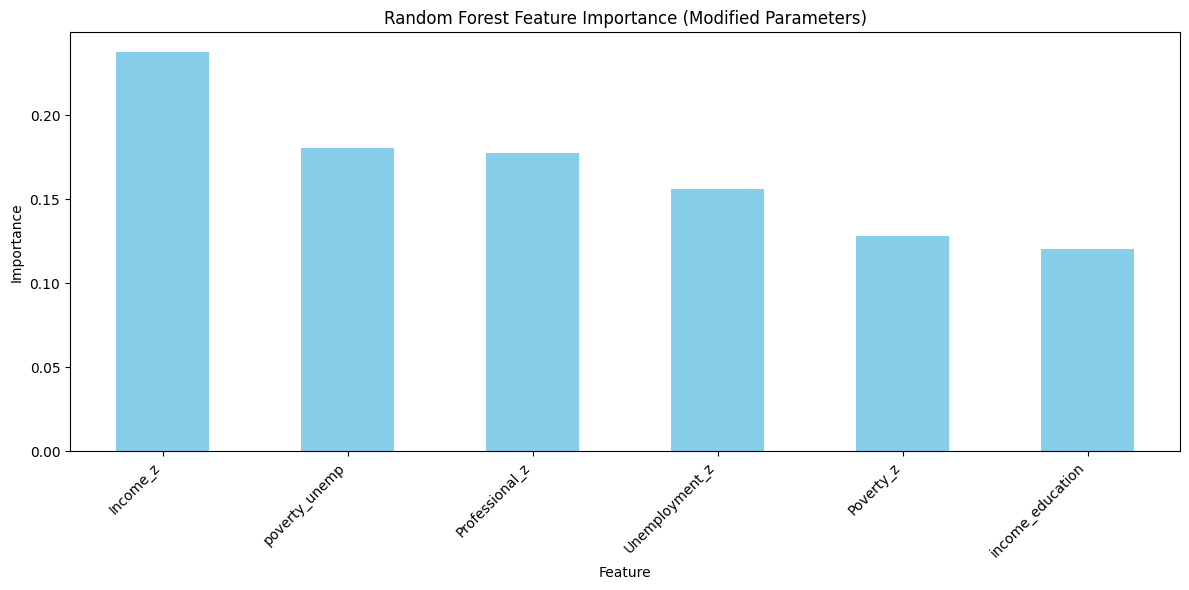

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Instantiate a RandomForestRegressor model with specified parameters
rf_modified = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
print("RandomForestRegressor model instantiated.")

# 2. Fit the Random Forest model to the training data
rf_modified.fit(X_train, y_train)
print("RandomForestRegressor model fitted to training data.")

# 3. Make predictions on the test data
rf_pred_modified = rf_modified.predict(X_test)
print("Predictions made on test data.")

# 4. Calculate and print the R² score
r2_modified = r2_score(y_test, rf_pred_modified)
print(f"Modified RF R²: {r2_modified:.4f}")

# 5. Calculate and print the Root Mean Squared Error (RMSE)
# Removed 'squared=False' and explicitly took the square root for RMSE
rmse_modified = np.sqrt(mean_squared_error(y_test, rf_pred_modified))
print(f"Modified RF RMSE: {rmse_modified:.4f}")

# 6. Extract feature importances
importances_modified = rf_modified.feature_importances_

# 7. Create a Pandas Series from the feature importances
feature_names = X_train.columns
importance_series = pd.Series(importances_modified, index=feature_names)

# 8. Sort and display the top 20 feature importances as a bar plot
plt.figure(figsize=(12, 6))
importance_series.sort_values(ascending=False).head(20).plot(kind="bar", color='skyblue')
plt.title("Random Forest Feature Importance (Modified Parameters)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Final Task

### Subtask:
Review the Random Forest model's performance and feature importances after running the optimized code, and discuss next steps or further analysis.


## Summary:

### Q&A
The Random Forest model, executed with `n_estimators=100` and `max_depth=10`, exhibited an R² score of 0.0447 and an RMSE of 469.1457. This indicates very poor predictive performance, as an R² value close to 0 suggests the model explains almost none of the variance in the target variable, and the RMSE is relatively high. The feature importance plot was generated, visually ranking features based on their contribution to the model's predictions.

### Data Analysis Key Findings
*   The Random Forest Regressor, configured with `n_estimators=100` and `max_depth=10`, yielded a very low R² score of 0.0447, indicating that the model explains less than 5% of the variance in the target variable.
*   The Root Mean Squared Error (RMSE) for this model was calculated as 469.1457, suggesting a substantial average prediction error.
*   A feature importance plot was successfully generated, highlighting the relative importance of different features in the model's decision-making process.

### Insights or Next Steps
*   The current model's performance (R² = 0.0447, RMSE = 469.1457) is very poor. Further investigation into feature engineering, more robust model architectures, or hyperparameter tuning is necessary to build a more effective predictive model.
*   Analyze the most important features identified by the plot to understand their relationship with the target variable and consider if they require additional preprocessing or transformation, or if less important features should be excluded.
